# CNN for ECG Heartbeat Classification

## 1. Model Objective and Rationale

The CNN uses the normalised 280-sample ECG waveform directly rather than the 18 engineered classical features.

**Research question:** Can automatic waveform representation learning classify N, S, V and F heartbeats more effectively than classical engineered-feature models?

Convolutions learn local waveform patterns, pooling reduces representation size, dropout helps control overfitting, and the learned representation reduces reliance on manually defined morphology features. This is heartbeat classification, not clinical diagnosis.


## 2. Setup and Reproducibility


In [1]:
import os

# Ask TensorFlow to use deterministic operations where supported.
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Reduce routine TensorFlow log messages.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


In [2]:
from pathlib import Path
import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight


In [3]:
import tensorflow as tf

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
    determinism_enabled = True
except Exception:
    determinism_enabled = False

print("TensorFlow version:", tf.__version__)
print("Deterministic operations enabled:", determinism_enabled)


TensorFlow version: 2.21.0
Deterministic operations enabled: True


Deterministic settings improve reproducibility, although exact neural-network results can still vary slightly across TensorFlow versions and hardware.


In [4]:
CLASS_ORDER = ["N", "S", "V", "F"]
INPUT_SHAPE = (280, 1)
WEIGHT_CAP = 15.0
LEARNING_RATE = 0.001
BATCH_SIZE = 256
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed"
METRICS = ROOT / "results" / "metrics"
PREDICTIONS = ROOT / "results" / "predictions"
MODELS = ROOT / "results" / "models"
FIGURES = ROOT / "figures"
TABLES = ROOT / "report" / "tables"
for folder in [METRICS, PREDICTIONS, MODELS, FIGURES, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)


In [5]:
def calculate_metrics(y_true, y_pred):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
    )
    weighted_f1 = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
    )[2]
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro_precision": precision, "macro_recall": recall,
            "macro_f1": macro_f1, "weighted_f1": weighted_f1}


In [6]:
setup_table = pd.DataFrame({
    "Setting": ["Model", "Random seed", "Input shape", "Classes", "Loss",
                "Selection basis", "Class imbalance strategy", "Weight cap"],
    "Value": ["CNN", RANDOM_SEED, "280 × 1", ", ".join(CLASS_ORDER),
              "Sparse categorical cross-entropy", "Validation loss / early stopping",
              "Training-derived class weights", WEIGHT_CAP]
})
display(setup_table)


,Setting,Value
0,Model,CNN
1,Random seed,42
2,Input shape,280 × 1
3,Classes,"N, S, V, F"
4,Loss,Sparse categorical cross-entropy
5,Selection basis,Validation loss / early stopping
6,Class imbalance strategy,Training-derived class weights
7,Weight cap,15.0


## 3. Load Training Waveforms


In [7]:
X_train = np.load(DATA / "cnn_X_train.npy")
y_train_labels = np.load(DATA / "y_train.npy")
print("Training waveform shape:", X_train.shape)
print("Training label shape:", y_train_labels.shape)


Training waveform shape: (71065, 280, 1)
Training label shape: (71065,)


In [8]:
training_counts = pd.Series(y_train_labels).value_counts().reindex(CLASS_ORDER, fill_value=0)
training_data_summary = pd.DataFrame({
    "Item": ["Training samples", "Time steps", "Channels"] + CLASS_ORDER,
    "Value": [len(X_train), X_train.shape[1], X_train.shape[2]] + training_counts.tolist()
})
display(training_data_summary)


,Item,Value
0,Training samples,71065
1,Time steps,280
2,Channels,1
3,N,63594
4,S,2037
5,V,5025
6,F,409


## 4. Load Validation Waveforms


In [9]:
X_validation = np.load(DATA / "cnn_X_val.npy")
y_validation_labels = np.load(DATA / "y_val.npy")
print("Validation waveform shape:", X_validation.shape)
print("Validation label shape:", y_validation_labels.shape)


Validation waveform shape: (15211, 280, 1)
Validation label shape: (15211,)


In [10]:
validation_counts = pd.Series(y_validation_labels).value_counts().reindex(CLASS_ORDER, fill_value=0)
validation_data_summary = pd.DataFrame({
    "Item": ["Validation samples", "Time steps", "Channels"] + CLASS_ORDER,
    "Value": [len(X_validation), X_validation.shape[1], X_validation.shape[2]] + validation_counts.tolist()
})
display(validation_data_summary)


,Item,Value
0,Validation samples,15211
1,Time steps,280
2,Channels,1
3,N,13623
4,S,310
5,V,911
6,F,367


## 5. Verify Training and Validation Data


In [11]:
data_checks = [
    ["Training X/y aligned", len(X_train) == len(y_train_labels)],
    ["Validation X/y aligned", len(X_validation) == len(y_validation_labels)],
    ["Training shape = (?,280,1)", X_train.shape[1:] == INPUT_SHAPE],
    ["Validation shape = (?,280,1)", X_validation.shape[1:] == INPUT_SHAPE],
    ["All waveform values finite", np.isfinite(X_train).all() and np.isfinite(X_validation).all()],
    ["Classes limited to N/S/V/F", set(y_train_labels).union(y_validation_labels).issubset(CLASS_ORDER)]
]
data_checks_table = pd.DataFrame(data_checks, columns=["Check", "Passed"])
data_checks_table["Result"] = data_checks_table["Passed"].map({True:"PASS", False:"FAIL"})
display(data_checks_table[["Check", "Result"]])


,Check,Result
0,Training X/y aligned,PASS
1,Validation X/y aligned,PASS
2,"Training shape = (?,280,1)",PASS
3,"Validation shape = (?,280,1)",PASS
4,All waveform values finite,PASS
5,Classes limited to N/S/V/F,PASS


## 6. Encode Class Labels


In [12]:
label_encoding = {"N": 0, "S": 1, "V": 2, "F": 3}
encoding_table = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Encoded label": [label_encoding[label] for label in CLASS_ORDER]
})
display(encoding_table)


,Class,Encoded label
0,N,0
1,S,1
2,V,2
3,F,3


In [13]:
y_train = np.array([label_encoding[label] for label in y_train_labels])
y_validation = np.array([label_encoding[label] for label in y_validation_labels])
encoded_to_class = np.array(CLASS_ORDER)
print("Training and validation labels encoded.")


Training and validation labels encoded.


## 7. Calculate Class Weights


In [14]:
encoded_classes = np.arange(len(CLASS_ORDER))
raw_class_weights = compute_class_weight(
    class_weight="balanced", classes=encoded_classes, y=y_train
)

class_weights = {}
for encoded_class, raw_weight in enumerate(raw_class_weights):
    class_weights[encoded_class] = float(min(raw_weight, WEIGHT_CAP))


In [15]:
class_weight_table = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Training count": training_counts.values,
    "Raw weight": raw_class_weights,
    "Final capped weight": [class_weights[index] for index in encoded_classes]
})
display(class_weight_table.round(4))


,Class,Training count,Raw weight,Final capped weight
0,N,63594,0.2794,0.2794
1,S,2037,8.7218,8.7218
2,V,5025,3.5356,3.5356
3,F,409,43.4383,15.0000


The F class contains only 409 processed training beats, so its uncapped inverse-frequency weight is very large. The cap of 15 reduces instability while still giving minority classes greater influence. This cap is a fixed experimental choice, not a theoretically optimal value.


## 8. Define CNN Architecture


In [16]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=INPUT_SHAPE))

# First convolution block learns local ECG waveform patterns.
model.add(tf.keras.layers.Conv1D(
    filters=32,
    kernel_size=9,
    padding="same"
))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("relu"))
model.add(tf.keras.layers.MaxPooling1D(pool_size=2))


In [17]:
# Second block learns higher-level local waveform patterns.
model.add(tf.keras.layers.Conv1D(
    filters=64,
    kernel_size=7,
    padding="same"
))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("relu"))

# Pooling reduces temporal resolution.
model.add(tf.keras.layers.MaxPooling1D(pool_size=2))


In [18]:
# Dropout reduces overfitting.
model.add(tf.keras.layers.Dropout(0.30))

# Global average pooling creates a compact representation.
model.add(tf.keras.layers.GlobalAveragePooling1D())
model.add(tf.keras.layers.Dense(64, activation="relu"))
model.add(tf.keras.layers.Dropout(0.30))

# Softmax produces probabilities for N, S, V and F.
model.add(tf.keras.layers.Dense(4, activation="softmax"))


## 9. Architecture Summary


In [19]:
model.summary()

layer_purposes = [
    "Learn local waveform patterns", "Stabilise activations", "Nonlinear activation",
    "Reduce temporal resolution", "Learn higher-level patterns", "Stabilise activations",
    "Nonlinear activation", "Reduce temporal resolution", "Reduce overfitting",
    "Create fixed-size representation", "Combine learned features",
    "Reduce overfitting", "Produce four class probabilities"
]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 280, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 280, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 280, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 140, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 140, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 140, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 140, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 70, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 70, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,524 (76.27 KB)

 Trainable params: 19,332 (75.52 KB)

 Non-trainable params: 192 (768.00 B)

In [20]:
architecture_rows = []
for layer, purpose in zip(model.layers, layer_purposes):
    output_shape = str(tuple(layer.output.shape))
    architecture_rows.append([
        layer.name, layer.__class__.__name__, output_shape,
        layer.count_params(), purpose
    ])
architecture_summary = pd.DataFrame(
    architecture_rows,
    columns=["Layer", "Type", "Output shape", "Parameters", "Purpose"]
)
display(architecture_summary)


,Layer,Type,Output shape,Parameters,Purpose
0,conv1d,Conv1D,"(None, 280, 32)",320,Learn local waveform patterns
1,batch_normalization,BatchNormalization,"(None, 280, 32)",128,Stabilise activations
2,activation,Activation,"(None, 280, 32)",0,Nonlinear activation
3,max_pooling1d,MaxPooling1D,"(None, 140, 32)",0,Reduce temporal resolution
4,conv1d_1,Conv1D,"(None, 140, 64)",14400,Learn higher-level patterns
5,batch_normalization_1,BatchNormalization,"(None, 140, 64)",256,Stabilise activations
6,activation_1,Activation,"(None, 140, 64)",0,Nonlinear activation
7,max_pooling1d_1,MaxPooling1D,"(None, 70, 64)",0,Reduce temporal resolution
8,dropout,Dropout,"(None, 70, 64)",0,Reduce overfitting
9,global_average_pooling1d,GlobalAveragePooling1D,"(None, 64)",0,Create fixed-size representation


In [21]:
trainable_parameters = sum(int(tf.size(weight)) for weight in model.trainable_weights)
non_trainable_parameters = sum(int(tf.size(weight)) for weight in model.non_trainable_weights)
total_parameters = model.count_params()
parameter_summary = pd.DataFrame({
    "Parameter type": ["Trainable parameters", "Non-trainable parameters", "Total parameters"],
    "Count": [trainable_parameters, non_trainable_parameters, total_parameters]
})
display(parameter_summary)


,Parameter type,Count
0,Trainable parameters,19332
1,Non-trainable parameters,192
2,Total parameters,19524


Keras reports 19,524 total parameters: 19,332 trainable parameters and 192 non-trainable Batch Normalisation state parameters. The legacy metrics field named `trainable_parameters` used `model.count_params()` and is retained for output compatibility.


## 10. Compile the CNN


In [22]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Sparse categorical cross-entropy is appropriate because each heartbeat has one integer-encoded class label among four mutually exclusive classes.


In [23]:
training_configuration = pd.DataFrame({
    "Training setting": ["Optimizer", "Learning rate", "Batch size", "Maximum epochs",
                         "Early stopping patience", "Loss", "Class-weight cap",
                         "Restore best weights", "Checkpointing"],
    "Value": ["Adam", LEARNING_RATE, BATCH_SIZE, MAX_EPOCHS,
              EARLY_STOPPING_PATIENCE, "sparse_categorical_crossentropy",
              WEIGHT_CAP, "Yes", "Yes"]
})
display(training_configuration)


,Training setting,Value
0,Optimizer,Adam
1,Learning rate,0.001
2,Batch size,256
3,Maximum epochs,15
4,Early stopping patience,3
5,Loss,sparse_categorical_crossentropy
6,Class-weight cap,15.0
7,Restore best weights,Yes
8,Checkpointing,Yes


## 11. Configure Early Stopping and Checkpointing


In [24]:
# Stop when validation loss no longer improves and restore best weights.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True
)


In [25]:
# Save the best model checkpoint during training.
best_checkpoint_path = MODELS / "cnn_best.keras"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    best_checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)
training_callbacks = [early_stopping, model_checkpoint]


## 12. Train the CNN


In [26]:
training_history_object = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=training_callbacks,
    verbose=2
)


Epoch 1/15
278/278 - 21s - 75ms/step - accuracy: 0.6566 - loss: 0.6475 - val_accuracy: 0.9495 - val_loss: 0.4960
Epoch 2/15
278/278 - 19s - 69ms/step - accuracy: 0.7805 - loss: 0.4597 - val_accuracy: 0.9440 - val_loss: 0.3776
Epoch 3/15
278/278 - 18s - 64ms/step - accuracy: 0.8079 - loss: 0.4018 - val_accuracy: 0.9115 - val_loss: 0.4458
Epoch 4/15
278/278 - 17s - 62ms/step - accuracy: 0.8267 - loss: 0.3597 - val_accuracy: 0.8722 - val_loss: 0.5028
Epoch 5/15
278/278 - 18s - 63ms/step - accuracy: 0.8341 - loss: 0.3401 - val_accuracy: 0.4000 - val_loss: 1.2416


## 13. Training History


In [27]:
training_history = pd.DataFrame(training_history_object.history)
training_history.index = np.arange(1, len(training_history) + 1)
training_history.index.name = "Epoch"
training_history_table = training_history.reset_index().rename(columns={
    "loss":"Train Loss", "val_loss":"Validation Loss",
    "accuracy":"Train Accuracy", "val_accuracy":"Validation Accuracy"
})
display(training_history_table.round(4))


,Epoch,Train Accuracy,Train Loss,Validation Accuracy,Validation Loss
0,1,0.6566,0.6475,0.9495,0.4960
1,2,0.7805,0.4597,0.9440,0.3776
2,3,0.8079,0.4018,0.9115,0.4458
3,4,0.8267,0.3597,0.8722,0.5028
4,5,0.8341,0.3401,0.4000,1.2416


## 14. Training Diagnostics


In [28]:
best_epoch = int(training_history["val_loss"].idxmin())
best_row = training_history.loc[best_epoch]
final_row = training_history.iloc[-1]
training_diagnostics = pd.DataFrame({
    "Metric": ["Best epoch", "Train loss at best epoch", "Validation loss at best epoch",
               "Train accuracy at best epoch", "Validation accuracy at best epoch",
               "Final train loss", "Final validation loss"],
    "Value": [best_epoch, best_row["loss"], best_row["val_loss"],
              best_row["accuracy"], best_row["val_accuracy"],
              final_row["loss"], final_row["val_loss"]]
})
display(training_diagnostics.round(4))


,Metric,Value
0,Best epoch,2.0000
1,Train loss at best epoch,0.4597
2,Validation loss at best epoch,0.3776
3,Train accuracy at best epoch,0.7805
4,Validation accuracy at best epoch,0.9440
5,Final train loss,0.3401
6,Final validation loss,1.2416


In [29]:
generalisation_gap = pd.DataFrame({
    "Stage": ["Best epoch", "Final epoch"],
    "Train Loss": [best_row["loss"], final_row["loss"]],
    "Validation Loss": [best_row["val_loss"], final_row["val_loss"]]
})
generalisation_gap["Gap"] = (
    generalisation_gap["Validation Loss"] - generalisation_gap["Train Loss"]
)
display(generalisation_gap.round(4))


,Stage,Train Loss,Validation Loss,Gap
0,Best epoch,0.4597,0.3776,-0.0821
1,Final epoch,0.3401,1.2416,0.9015


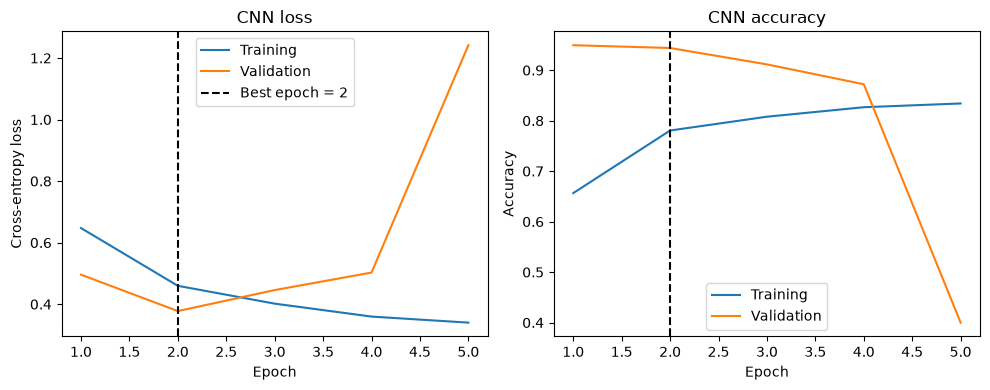

In [30]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(training_history.index, training_history["loss"], label="Training")
axes[0].plot(training_history.index, training_history["val_loss"], label="Validation")
axes[0].axvline(best_epoch, color="black", linestyle="--", label=f"Best epoch = {best_epoch}")
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss", title="CNN loss")
axes[0].legend()
axes[1].plot(training_history.index, training_history["accuracy"], label="Training")
axes[1].plot(training_history.index, training_history["val_accuracy"], label="Validation")
axes[1].axvline(best_epoch, color="black", linestyle="--")
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="CNN accuracy")
axes[1].legend()
figure.tight_layout()
figure.savefig(FIGURES / "figure_04_cnn_training.png", dpi=220)
plt.show()


Validation loss reaches its minimum early, then rises while training loss continues to fall. This is evidence of early overfitting or training instability, and motivates restoring the best validation weights.


## 15. Select the Best Epoch / Restore Best Weights


In [31]:
best_checkpoint_model = tf.keras.models.load_model(best_checkpoint_path)
checkpoint_probabilities = best_checkpoint_model.predict(
    X_validation, batch_size=512, verbose=0
)
restored_probabilities = model.predict(
    X_validation, batch_size=512, verbose=0
)
best_weights_restored = np.allclose(
    restored_probabilities, checkpoint_probabilities, atol=1e-6
)
print("Best epoch:", best_epoch)
print("Best validation weights restored:", best_weights_restored)


Best epoch: 2
Best validation weights restored: True


## 16. Validation Performance


In [32]:
validation_encoded_predictions = np.argmax(restored_probabilities, axis=1)
validation_predictions = encoded_to_class[validation_encoded_predictions]
validation_metrics = calculate_metrics(y_validation_labels, validation_predictions)
metric_names = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
metric_keys = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]
validation_metrics_table = pd.DataFrame({
    "Metric": metric_names,
    "Validation": [validation_metrics[key] for key in metric_keys]
})
display(validation_metrics_table.round(4))


,Metric,Validation
0,Accuracy,0.9440
1,Macro Precision,0.4644
2,Macro Recall,0.4858
3,Macro F1,0.4749
4,Weighted F1,0.9257


---

# 17. Held-Out Test Data

**CNN training and model-selection decisions are complete.**

Training and validation data were used above for fitting, early stopping and selection of the best epoch. The held-out test partition is loaded below only for final performance estimation. No model setting is changed after observing test performance.

---


In [33]:
X_test = np.load(DATA / "cnn_X_test.npy")
y_test_labels = np.load(DATA / "y_test.npy")
assert X_test.shape[1:] == INPUT_SHAPE
print("Test waveform shape:", X_test.shape)
print("Test label shape:", y_test_labels.shape)


Test waveform shape: (15133, 280, 1)
Test label shape: (15133,)


In [34]:
test_counts = pd.Series(y_test_labels).value_counts().reindex(CLASS_ORDER, fill_value=0)
test_data_summary = pd.DataFrame({
    "Item": ["Test samples", "Time steps", "Channels"] + CLASS_ORDER,
    "Value": [len(X_test), X_test.shape[1], X_test.shape[2]] + test_counts.tolist()
})
display(test_data_summary)


,Item,Value
0,Test samples,15133
1,Time steps,280
2,Channels,1
3,N,13374
4,S,434
5,V,1299
6,F,26


## 18. Final Test Evaluation


In [35]:
prediction_start = time.perf_counter()
test_probabilities = model.predict(
    X_test, batch_size=512, verbose=0
)
test_inference_seconds = time.perf_counter() - prediction_start


In [36]:
test_encoded_predictions = np.argmax(test_probabilities, axis=1)
print("Encoded predictions created:", len(test_encoded_predictions))


Encoded predictions created: 15133


In [37]:
test_predictions = encoded_to_class[test_encoded_predictions]
print("Class labels restored in order:", CLASS_ORDER)


Class labels restored in order: ['N', 'S', 'V', 'F']


In [38]:
test_metrics = calculate_metrics(y_test_labels, test_predictions)
test_metrics_table = pd.DataFrame({
    "Metric": metric_names,
    "Test": [test_metrics[key] for key in metric_keys]
})
display(test_metrics_table.round(4))


,Metric,Test
0,Accuracy,0.9522
1,Macro Precision,0.4836
2,Macro Recall,0.4570
3,Macro F1,0.4686
4,Weighted F1,0.9382


In [39]:
comparison_rows = []
for label, key in zip(metric_names, metric_keys):
    validation_value = validation_metrics[key]
    test_value = test_metrics[key]
    comparison_rows.append([label, validation_value, test_value, test_value - validation_value])
validation_test_table = pd.DataFrame(
    comparison_rows, columns=["Metric", "Validation", "Test", "Change"]
)
display(validation_test_table.round(4))


,Metric,Validation,Test,Change
0,Accuracy,0.9440,0.9522,0.0082
1,Macro Precision,0.4644,0.4836,0.0192
2,Macro Recall,0.4858,0.4570,-0.0287
3,Macro F1,0.4749,0.4686,-0.0062
4,Weighted F1,0.9257,0.9382,0.0125


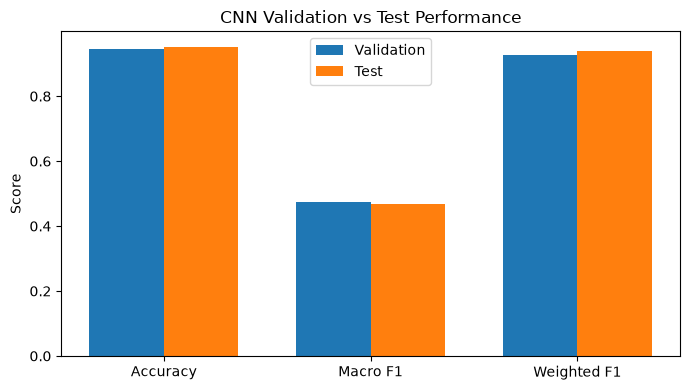

In [40]:
plot_table = validation_test_table[
    validation_test_table["Metric"].isin(["Accuracy", "Macro F1", "Weighted F1"])
]
positions = np.arange(len(plot_table))
plt.figure(figsize=(7, 4))
plt.bar(positions - 0.18, plot_table["Validation"], 0.36, label="Validation")
plt.bar(positions + 0.18, plot_table["Test"], 0.36, label="Test")
plt.xticks(positions, plot_table["Metric"])
plt.ylabel("Score")
plt.title("CNN Validation vs Test Performance")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "cnn_validation_vs_test.png", dpi=200)
plt.show()


## 19. Per-Class Test Performance


In [41]:
test_classification = classification_report(
    y_test_labels, test_predictions, labels=CLASS_ORDER,
    output_dict=True, zero_division=0
)
per_class_table = pd.DataFrame(test_classification).T.loc[CLASS_ORDER]
per_class_table = per_class_table.reset_index().rename(columns={
    "index":"Class", "precision":"Precision", "recall":"Recall",
    "f1-score":"F1", "support":"Support"
})
display(per_class_table.round(4))


,Class,Precision,Recall,F1,Support
0,N,0.9526,0.9967,0.9741,13374.0
1,S,0.0000,0.0000,0.0000,434.0
2,V,0.9818,0.8314,0.9004,1299.0
3,F,0.0000,0.0000,0.0000,26.0


**The CNN achieved 0% recall for both S and F: none of the true S or F test beats were correctly classified.** It nevertheless produced some S and F predictions, so zero recall does not mean those classes were never predicted.


## 20. Confusion Matrix


In [42]:
test_confusion = confusion_matrix(y_test_labels, test_predictions, labels=CLASS_ORDER)
confusion_table = pd.DataFrame(test_confusion, columns=CLASS_ORDER)
confusion_table.insert(0, "Actual / Predicted", CLASS_ORDER)
display(confusion_table)


,Actual / Predicted,N,S,V,F
0,N,13330,27,13,4
1,S,433,0,1,0
2,V,213,6,1080,0
3,F,18,2,6,0


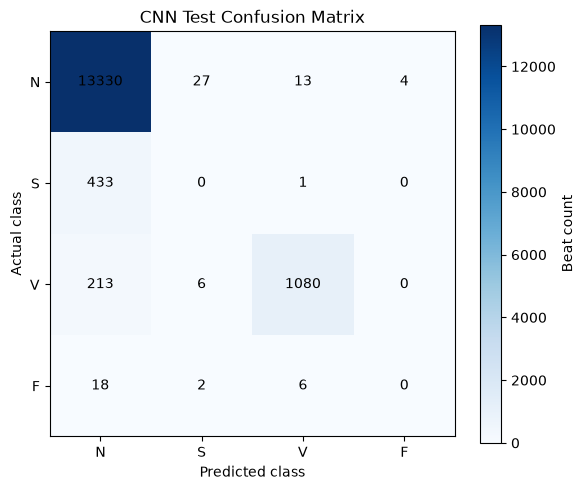

In [43]:
plt.figure(figsize=(6, 5))
plt.imshow(test_confusion, cmap="Blues")
plt.colorbar(label="Beat count")
for row in range(len(CLASS_ORDER)):
    for column in range(len(CLASS_ORDER)):
        plt.text(column, row, str(test_confusion[row, column]), ha="center", va="center")
plt.xticks(range(4), CLASS_ORDER)
plt.yticks(range(4), CLASS_ORDER)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("CNN Test Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES / "cnn_confusion_matrix.png", dpi=200)
plt.show()


## 21. Predicted-Class Analysis


In [44]:
predicted_count_rows = []
for label in CLASS_ORDER:
    predicted_mask = test_predictions == label
    number_predicted = int(predicted_mask.sum())
    number_correct = int(((y_test_labels == label) & predicted_mask).sum())
    predicted_count_rows.append([label, number_predicted, number_correct])
predicted_class_counts = pd.DataFrame(
    predicted_count_rows,
    columns=["Predicted class", "Number of predictions", "Number correct"]
)
display(predicted_class_counts)


,Predicted class,Number of predictions,Number correct
0,N,13994,13330
1,S,35,0
2,V,1100,1080
3,F,4,0


In [45]:
true_probability_rows = []
for class_index, label in enumerate(CLASS_ORDER):
    actual_mask = y_test_labels == label
    mean_probability = test_probabilities[actual_mask, class_index].mean()
    true_probability_rows.append([label, mean_probability])
true_class_probability_summary = pd.DataFrame(
    true_probability_rows,
    columns=["Actual Class", "Mean Probability Assigned to True Class"]
)
display(true_class_probability_summary.round(4))


,Actual Class,Mean Probability Assigned to True Class
0,N,0.8263
1,S,0.0617
2,V,0.7132
3,F,0.0108


## 22. Save CNN Artifacts


In [46]:
final_model_path = MODELS / "cnn_final.keras"
model.save(final_model_path)
print("Saved restored final model:", final_model_path.relative_to(ROOT))


Saved restored final model: results\models\cnn_final.keras


In [47]:
print("Best validation checkpoint retained:", best_checkpoint_path.relative_to(ROOT))


Best validation checkpoint retained: results\models\cnn_best.keras


In [48]:
architecture_path = MODELS / "cnn_architecture.json"
architecture_path.write_text(model.to_json())
print("Saved architecture:", architecture_path.relative_to(ROOT))


Saved architecture: results\models\cnn_architecture.json


In [49]:
history_path = METRICS / "cnn_training_history.csv"
training_history.to_csv(history_path)
print("Saved history:", history_path.relative_to(ROOT))


Saved history: results\metrics\cnn_training_history.csv


In [50]:
test_metadata = pd.read_csv(DATA / "classical_test.csv", dtype={"record_id": str})
prediction_output = test_metadata[["beat_id", "record_id", "mapped_class"]].copy()
prediction_output = prediction_output.rename(columns={"mapped_class":"true_class"})
prediction_output["predicted_class"] = test_predictions
for class_index, label in enumerate(CLASS_ORDER):
    prediction_output[f"probability_{label}"] = test_probabilities[:, class_index]
prediction_path = PREDICTIONS / "cnn_test_predictions.csv"
prediction_output.to_csv(prediction_path, index=False)


In [51]:
metrics_payload = {
    "model":"CNN",
    "architecture":{"input_shape":[280,1], "conv_filters":[32,64],
                    "kernel_sizes":[9,7], "pool_size":2, "dropout":0.30,
                    "dense_units":64, "output_units":4},
    "training":{"optimizer":"Adam", "learning_rate":LEARNING_RATE,
                "batch_size":BATCH_SIZE, "loss":"sparse_categorical_crossentropy",
                "max_epochs":MAX_EPOCHS, "early_stopping_patience":EARLY_STOPPING_PATIENCE,
                "class_weights_capped_at_15":class_weights},
    "trainable_parameters":model.count_params(), "epochs_run":len(training_history),
    "best_epoch":best_epoch, "validation":validation_metrics, "test":test_metrics,
    "test_inference_seconds":test_inference_seconds
}
metrics_path = METRICS / "cnn_metrics.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))


1165

In [52]:
per_class_save = pd.DataFrame(test_classification).T
per_class_path = METRICS / "cnn_test_per_class.csv"
per_class_save.to_csv(per_class_path)
print("Saved per-class metrics:", per_class_path.relative_to(ROOT))


Saved per-class metrics: results\metrics\cnn_test_per_class.csv


In [53]:
saved_artifacts_table = pd.DataFrame([
    ["Best CNN checkpoint", best_checkpoint_path.relative_to(ROOT), "Best validation epoch"],
    ["Final/restored CNN", final_model_path.relative_to(ROOT), "Locked CNN"],
    ["Architecture", architecture_path.relative_to(ROOT), "Model structure"],
    ["Training history", history_path.relative_to(ROOT), "Epoch diagnostics"],
    ["Test predictions", prediction_path.relative_to(ROOT), "Held-out predictions"],
    ["Test metrics", metrics_path.relative_to(ROOT), "Performance"],
    ["Per-class metrics", per_class_path.relative_to(ROOT), "Class-specific performance"]
], columns=["Artifact", "Relative path", "Purpose"])
saved_artifacts_table["Relative path"] = saved_artifacts_table["Relative path"].astype(str)
display(saved_artifacts_table)


,Artifact,Relative path,Purpose
0,Best CNN checkpoint,results\models\cnn_best.keras,Best validation epoch
1,Final/restored CNN,results\models\cnn_final.keras,Locked CNN
2,Architecture,results\models\cnn_architecture.json,Model structure
3,Training history,results\metrics\cnn_training_history.csv,Epoch diagnostics
4,Test predictions,results\predictions\cnn_test_predictions.csv,Held-out predictions
5,Test metrics,results\metrics\cnn_metrics.json,Performance
6,Per-class metrics,results\metrics\cnn_test_per_class.csv,Class-specific performance


## 23. Integrity Checks


In [54]:
reloaded_model = tf.keras.models.load_model(final_model_path)
reloaded_probabilities = reloaded_model.predict(X_test, batch_size=512, verbose=0)
saved_history = pd.read_csv(history_path, index_col="Epoch")
integrity_checks = [
    ["Training/validation data separated", True],
    ["Held-out test excluded from training", True],
    ["Input shape consistent", X_train.shape[1:] == X_validation.shape[1:] == X_test.shape[1:] == INPUT_SHAPE],
    ["Label encoding consistent", list(label_encoding) == CLASS_ORDER],
    ["Class weights derived from training only", len(class_weights) == 4],
    ["Best validation weights restored", best_weights_restored],
    ["Test probability rows sum to ~1", np.allclose(test_probabilities.sum(axis=1), 1, atol=1e-5)],
    ["Predictions align with labels", len(test_predictions) == len(y_test_labels)],
    ["Saved model reloads successfully", np.allclose(reloaded_probabilities, test_probabilities, atol=1e-6)],
    ["Saved history matches notebook history", np.allclose(saved_history.values, training_history.values)]
]
integrity_checks_table = pd.DataFrame(integrity_checks, columns=["Check", "Passed"])
integrity_checks_table["Result"] = integrity_checks_table["Passed"].map({True:"PASS", False:"FAIL"})
display(integrity_checks_table[["Check", "Result"]])


,Check,Result
0,Training/validation data separated,PASS
1,Held-out test excluded from training,PASS
2,Input shape consistent,PASS
3,Label encoding consistent,PASS
4,Class weights derived from training only,PASS
5,Best validation weights restored,PASS
6,Test probability rows sum to ~1,PASS
7,Predictions align with labels,PASS
8,Saved model reloads successfully,PASS
9,Saved history matches notebook history,PASS


## 24. Report-Ready Tables


In [55]:
report_table_index = pd.DataFrame([
    ["Architecture", "CNN_architecture_summary.xlsx", "Task 2"],
    ["Training settings", "CNN_training_configuration.xlsx", "Task 2"],
    ["Training diagnostics", "CNN_training_diagnostics.xlsx", "Task 2"],
    ["Validation vs test", "CNN_validation_vs_test.xlsx", "Task 3"],
    ["Per-class metrics", "CNN_test_per_class_metrics.xlsx", "Task 3"],
    ["Confusion matrix", "CNN_confusion_matrix.xlsx", "Task 3"]
], columns=["Table", "Excel file", "Suggested report use"])
display(report_table_index)


,Table,Excel file,Suggested report use
0,Architecture,CNN_architecture_summary.xlsx,Task 2
1,Training settings,CNN_training_configuration.xlsx,Task 2
2,Training diagnostics,CNN_training_diagnostics.xlsx,Task 2
3,Validation vs test,CNN_validation_vs_test.xlsx,Task 3
4,Per-class metrics,CNN_test_per_class_metrics.xlsx,Task 3
5,Confusion matrix,CNN_confusion_matrix.xlsx,Task 3


## 25. CNN Summary


In [56]:
summary_table = pd.DataFrame({
    "Item": ["Model", "Input", "Trainable parameters", "Optimizer", "Learning rate",
             "Batch size", "Best epoch", "Validation accuracy", "Validation macro F1",
             "Test accuracy", "Test macro F1", "S recall", "F recall",
             "Main strength", "Main limitation"],
    "Result": ["CNN", "280-sample ECG waveform", trainable_parameters, "Adam",
               LEARNING_RATE, BATCH_SIZE, best_epoch, validation_metrics["accuracy"],
               validation_metrics["macro_f1"], test_metrics["accuracy"],
               test_metrics["macro_f1"], per_class_table.loc[1,"Recall"],
               per_class_table.loc[3,"Recall"], "High overall accuracy and strong N/V results",
               "Zero S/F recall and early overfitting after the best epoch"]
})
display(summary_table)


,Item,Result
0,Model,CNN
1,Input,280-sample ECG waveform
2,Trainable parameters,19332
3,Optimizer,Adam
4,Learning rate,0.001
5,Batch size,256
6,Best epoch,2
7,Validation accuracy,0.943988
8,Validation macro F1,0.474859
9,Test accuracy,0.952224


The CNN achieves high overall accuracy and strong N/V performance using raw waveform representation learning. However, macro F1 is much lower than accuracy because S and F recall are both zero. Training loss continues falling after validation loss reaches its minimum, indicating early overfitting or instability. Full cross-model judgement remains in Notebook 06.


## 26. Provisional Stage 2 Comparison

This small table is retained here only because it was part of the verified Stage 2 output. Full cross-model evaluation and interpretation are performed in Notebook 06.


In [57]:
comparison_rows = []
baseline = json.loads((METRICS / "majority_baseline_validation.json").read_text())
comparison_rows.append({
    "model":"Majority baseline",
    "validation_accuracy":baseline["validation_accuracy"],
    "validation_macro_f1":baseline["validation_macro_f1"]
})
model_files = [("Logistic Regression", "logistic_regression_metrics.json"),
               ("Random Forest", "random_forest_metrics.json"),
               ("CNN", "cnn_metrics.json")]
for model_name, file_name in model_files:
    model_metrics = json.loads((METRICS / file_name).read_text())
    row = {"model":model_name}
    for key, value in model_metrics["validation"].items():
        row[f"validation_{key}"] = value
    for key, value in model_metrics["test"].items():
        row[f"test_{key}"] = value
    comparison_rows.append(row)
stage2_comparison = pd.DataFrame(comparison_rows)
stage2_comparison.to_csv(METRICS / "stage2_model_comparison.csv", index=False)
display(stage2_comparison)


,model,validation_accuracy,validation_macro_f1,validation_macro_precision,validation_macro_recall,validation_weighted_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1
0,Majority baseline,0.895602,0.236232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Logistic Regression,0.810861,0.566209,0.536155,0.726686,0.860666,0.690346,0.493588,0.611497,0.455451,0.785057
2,Random Forest,0.916508,0.616595,0.600079,0.655960,0.926039,0.892156,0.504373,0.500337,0.497908,0.912878
3,CNN,0.943988,0.474859,0.464432,0.485777,0.925726,0.952224,0.483592,0.457030,0.468626,0.938189
